# Polynomial Regression, Underfitting / Overfitting, and Bias-Variance Tradeoff

**Scaler CML | Applied ML (Intro)**

## How to use this notebook

1. Run cells **top to bottom** (Restart & Run All is fine).
2. Markdown cells are the teaching track; code cells are demos you and students can re-run.
3. **Discuss:** / **Think:** prompts are open questions for class discussion. Do not treat them as quiz spoilers.
4. Quizzes appear inline with choices only. There is **no answer key** in this notebook.
5. Optional post-read for Gradient Descent variants: [Mini-Batch GD Colab](https://colab.research.google.com/drive/1EXhY2Ax1lPp7cc03bHvwtc-UQ78t6iKI?usp=sharing).

# 1. Agenda

Today we connect optimization choices to model complexity:

1. **Gradient Descent Variants** (Batch vs SGD vs Mini-Batch)
2. **Polynomial Regression** (feature engineering that stays linear in weights)
3. **Generalization and Occam's Razor**
4. **Underfitting and Overfitting**
5. **Bias-Variance Tradeoff**

By the end you should be able to pick a sensible polynomial degree using train vs test behavior, not training fit alone.

# 2. Gradient Descent Variants

## Quick recall: weight update

In linear regression with gradient descent, weights update roughly as:

$$
w := w - \eta \cdot \nabla_w J(w)
$$

where $\eta$ is the learning rate and $J$ is the loss (often MSE).

## Potential problem with Batch Gradient Descent

**Batch GD** uses **all** $n$ training points to compute the gradient each step.

- Gradient estimate is stable and accurate.
- Each step is **expensive** when $n$ is large (full pass over the data per update).
- Wall-clock time to reach a good solution can be high on big datasets.

**Think:** If each update needs a full pass over millions of rows, how many updates can you afford in a fixed training budget?

## SGD (Stochastic Gradient Descent)

Idea: use **one** random datapoint (or one random example) per update.

- Very cheap updates.
- Noisy gradient: path to the optimum **fluctuates** a lot.
- Can escape some flat regions, but the noise can also make final convergence jittery.

## Mini-Batch Gradient Descent

Use a batch of size $k$ where typically $1 < k \ll n$.

Possible batch sizes in practice:

| Setting | Batch size $k$ | Name |
|---|---|---|
| Full data | $k = n$ | Batch GD |
| Single point | $k = 1$ | SGD |
| Chunk | e.g. 32, 64, 128, 256 | Mini-Batch GD |

Mini-batch **vectorizes** over $k$ examples: better GPU/CPU utilization than pure SGD, much cheaper than full batch.

### Comparing Batch vs SGD vs Mini-Batch

| Aspect | Batch GD | SGD | Mini-Batch GD |
|---|---|---|---|
| Data per update | All $n$ | 1 | $k$ |
| Gradient noise | Lowest | Highest | Medium |
| Time per update | Highest | Lowest | Medium |
| Path to optimum | Smooth, fewer weight swings | Very noisy | Mild fluctuations |
| Typical practical use | Small data / closed form preferred | Rare as $k=1$ in deep learning | Default in modern ML |

**Observe (contour intuition):**

1. **Batch GD:** whole-data gradients, fewest fluctuations per iteration, but each iteration is slow.
2. **SGD:** single (possibly noisy) point, **maximum** weight fluctuations.
3. **Mini-Batch GD:** chunks of data; usually the best speed/stability tradeoff, with only mild fluctuations.

**Discuss:** For $k = 256$, is the gradient "exact"? Why might an approximate gradient still be good enough?

### Post-read (code)

Optional deeper code walkthrough (Mini-Batch GD):  
https://colab.research.google.com/drive/1EXhY2Ax1lPp7cc03bHvwtc-UQ78t6iKI?usp=sharing

In [1]:
# Optional tiny sketch: one conceptual mini-batch update (not a full trainer)
import numpy as np

def mse_grad_w(X_batch, y_batch, w):
    """Gradient of MSE w.r.t. weights for a batch. X includes bias column if needed."""
    n = X_batch.shape[0]
    residuals = X_batch @ w - y_batch
    return (2.0 / n) * (X_batch.T @ residuals)

# Toy numbers
rng = np.random.default_rng(0)
X = np.c_[np.ones(8), rng.normal(size=8)]
y = 2 * X[:, 1] + 0.1 * rng.normal(size=8)
w = np.zeros(2)
eta, k = 0.1, 4
idx = rng.choice(8, size=k, replace=False)
w = w - eta * mse_grad_w(X[idx], y[idx], w)
print("One mini-batch update -> w =", w)

One mini-batch update -> w = [0.10309825 0.21065761]


# Quiz 1

**Which statement is true about mini-batch gradient descent?**

- It guarantees convergence to the global minima
- It may converge to a local minima due to the weight fluctuations
- It requires a very high learning rate.
- It is not suitable for large datasets.

# 4. Polynomial Regression (Concepts)

## Will linear regression work?

If the relationship between $x$ and $y$ is roughly a straight line, ordinary linear regression is a good fit.

If the data is clearly **curved** (non-linear in $x$), a straight line underfits the pattern.

**Discuss:** Sketch a scatter that looks quadratic. Where does a degree-1 line fail?

## Making linear regression "quadratic" via features

Add engineered features. For one raw feature $f_1$:

$$
\hat{y} = w_0 + w_1 f_1 + w_2 f_1^{2}
$$

Important:

- The model is **non-linear in the input** $f_1$.
- It is still **linear in the weights** $w_0, w_1, w_2$.
- So we can still train with ordinary least squares / linear regression solvers.

In feature space $(f_1, f_2)$ with $f_2 = f_1^{2}$, the predictor is a **plane**. Projected back onto the $f_1$ axis, that plane looks like a **curve**.

### Multicollinearity note

$f_1$ and $f_1^{2}$ are related (not independent), so collinearity can rise as we add higher powers. Standardization and careful degree selection help in practice.

### Higher degree (general form)

$$
\hat{y} = w_0 + w_1 f_1 + w_2 f_1^{2} + \cdots + w_d f_1^{d}
$$

The **degree** of the polynomial is the highest power $d$.

**Think:** Why do we say "polynomial regression is still a linear model"?

# Quiz 2

**What is the degree of a polynomial in polynomial regression?**

- The number of features in the dataset.
- The number of training examples in the dataset.
- The highest power of the feature in the polynomial equation.
- The number of coefficients in the polynomial equation.

# 6. Polynomial Regression Code

We synthesize **50** points (`seed=1`) from a known polynomial plus noise, then compare:

1. Degree-1 linear fit
2. Manual $X^2$ feature
3. `PolynomialFeatures` for degrees 1 through 5

We report **Adjusted R-squared** because adding powers always increases raw $R^2$ on the training set.

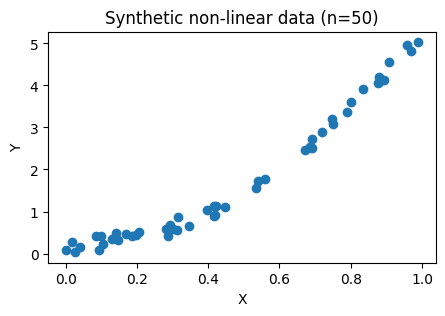

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)
X = np.random.rand(50, 1)
y = (
    0.7 * (X ** 5)
    - 2.1 * (X ** 4)
    + 2.7 * (X ** 3)
    + 3.5 * (X ** 2)
    + 0.3 * X
    + 0.4 * np.random.rand(50, 1)
)  # no data in the world is perfect

fig = plt.figure(figsize=(5, 3))
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Synthetic non-linear data (n=50)")
plt.show()

In [9]:
X

array([[4.17022005e-01],
       [7.20324493e-01],
       [1.14374817e-04],
       [3.02332573e-01],
       [1.46755891e-01],
       [9.23385948e-02],
       [1.86260211e-01],
       [3.45560727e-01],
       [3.96767474e-01],
       [5.38816734e-01],
       [4.19194514e-01],
       [6.85219500e-01],
       [2.04452250e-01],
       [8.78117436e-01],
       [2.73875932e-02],
       [6.70467510e-01],
       [4.17304802e-01],
       [5.58689828e-01],
       [1.40386939e-01],
       [1.98101489e-01],
       [8.00744569e-01],
       [9.68261576e-01],
       [3.13424178e-01],
       [6.92322616e-01],
       [8.76389152e-01],
       [8.94606664e-01],
       [8.50442114e-02],
       [3.90547832e-02],
       [1.69830420e-01],
       [8.78142503e-01],
       [9.83468338e-02],
       [4.21107625e-01],
       [9.57889530e-01],
       [5.33165285e-01],
       [6.91877114e-01],
       [3.15515631e-01],
       [6.86500928e-01],
       [8.34625672e-01],
       [1.82882773e-02],
       [7.50144315e-01],


Adj. R-square (degree 1): 0.9332371047707784


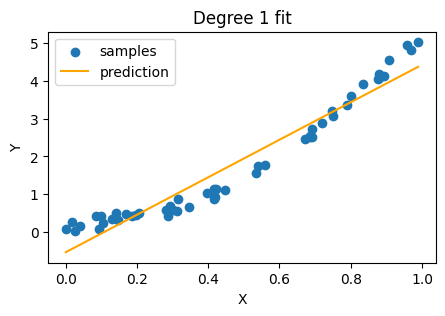

In [3]:
def r2_score(y, y_hat):
    num = np.sum((y - y_hat) ** 2)
    denom = np.sum((y - y.mean()) ** 2)
    return 1 - num / denom


def adj_r(r_sq, X_feat, Y):
    """Adjusted R^2 using the *feature matrix* column count (after transforms).

    When p >= n - 1 the usual formula is undefined; return np.nan so plots
    stay honest instead of crashing or inventing a score.
    """
    n = len(Y)
    p = X_feat.shape[1]
    denom = n - p - 1
    if denom <= 0:
        return np.nan
    return 1 - ((1 - r_sq) * (n - 1)) / denom


from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)
output = model.predict(X)

print("Adj. R-square (degree 1):", adj_r(r2_score(y, output), X, y))

fig = plt.figure(figsize=(5, 3))
plt.scatter(X, y, label="samples")
# sort for a clean line plot
order = np.argsort(X[:, 0])
plt.plot(X[order], output[order], label="prediction", color="orange")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.title("Degree 1 fit")
plt.show()

### Add $X^2$ as a feature

**Discuss:** Before running, do you expect Adjusted R-squared to rise a little or a lot?

In [12]:
#  np.hstack([X, X ** 2])

Adj. R-square (manual degree 2): 0.9946802186938059


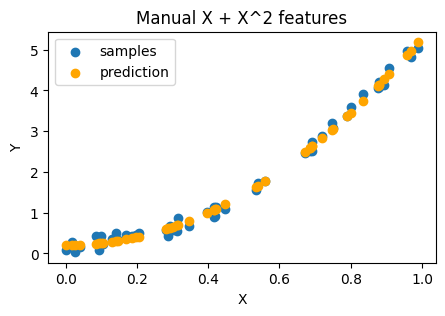

In [4]:
# adding new feature X^2
X_deg2 = np.hstack([X, X ** 2])
model_deg2 = LinearRegression()
model_deg2.fit(X_deg2, y)
output = model_deg2.predict(X_deg2) # Predictions

print("Adj. R-square (manual degree 2):", adj_r(r2_score(y, output), X_deg2, y))

fig = plt.figure(figsize=(5, 3))
plt.scatter(X, y, label="samples")
plt.scatter(X, output, label="prediction", color="orange")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.title("Manual X + X^2 features")
plt.show()

**Observe:** Adding a non-linear feature often improves fit a lot when the true curve is curved.

### `PolynomialFeatures` for degrees 1 to 5

We standardize polynomial features before fitting (helps numerical stability as powers grow).

Adj. R-square for Model Degree 1: 0.9318166176382416


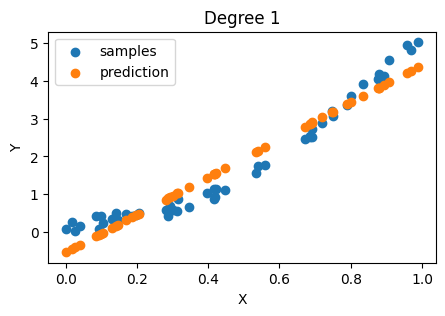

Adj. R-square for Model Degree 2: 0.994564571274106


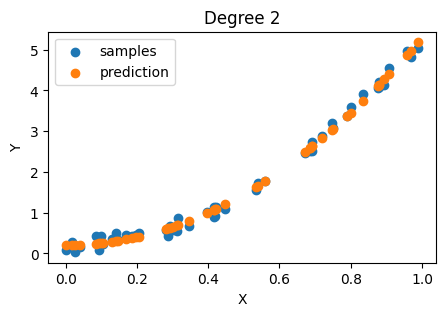

Adj. R-square for Model Degree 3: 0.9944735532438161


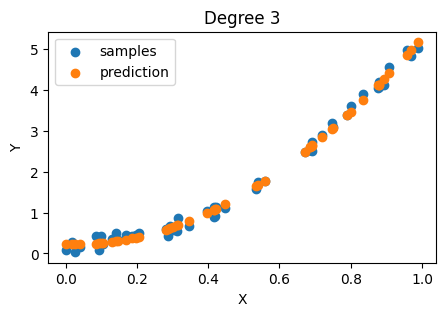

Adj. R-square for Model Degree 4: 0.9954971261912255


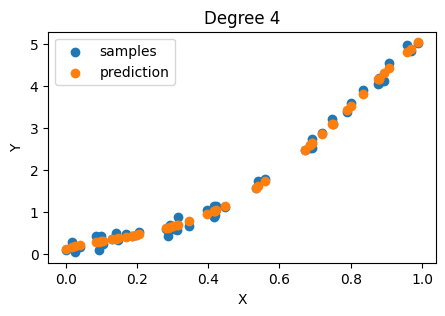

Adj. R-square for Model Degree 5: 0.995442243943045


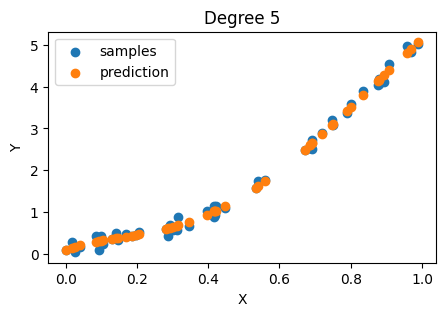

In [5]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# Using degrees 1 to 5, and seeing performance of the model
for i in range(1, 6):
    poly = PolynomialFeatures(i) # 2 -> (x, x2) # 3- > (x, x2, x3)
    X_poly = poly.fit_transform(X)

    scaler = StandardScaler()
    X_poly_scaled = scaler.fit_transform(X_poly)

    model = LinearRegression()
    model.fit(X_poly_scaled, y)
    output = model.predict(X_poly_scaled)

    print(
        f"Adj. R-square for Model Degree {i}: "
        f"{adj_r(r2_score(y, output), X_poly_scaled, y)}"
    )

    fig = plt.figure(figsize=(5, 3))
    plt.scatter(X, y, label="samples")
    plt.scatter(X, output, label="prediction")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(f"Degree {i}")
    plt.legend()
    plt.show()

**Observe:** As degree increases (here, 1 to 5), training Adjusted R-squared generally improves. That does **not** automatically mean higher is better for unseen data.

Next: a quick pause on **why we report Adjusted $R^2$** instead of raw $R^2$ when features (degrees) grow.


# Why Adjusted $R^2$ (not raw $R^2$)?

As we add polynomial powers, the model gets more parameters. That changes iow we should read "goodness of fit."

## Raw $R^2$

$$
R^2 = 1 - \frac{\mathrm{SS}_{\mathrm{res}}}{\mathrm{SS}_{\mathrm{tot}}}
$$

- Fraction of variance in $y$ explained by the model on **this** dataset.
- On the **training** set, $R^2$ **never decreases** when you add features (including $x^2, x^3, \ldots$), even if those features are useless.
- So training $R^2$ alone will **always** push you toward higher degree.

## Adjusted $R^2$

$$
R^2_{\mathrm{adj}} = 1 - (1 - R^2)\frac{n - 1}{n - p - 1}
$$

where $n$ = number of samples and $p$ = number of **features used by the model** (after `PolynomialFeatures`, use that column count).

- Penalizes extra parameters: if a new feature barely helps, Adjusted $R^2$ can **drop**.
- Fairer for comparing degree 1 vs 2 vs 5 on the same training set.
- Still **not** a substitute for a train/test (or validation) check. Adjusted $R^2$ on train can look fine while the model overfits.

**Rule of thumb for this class:** when comparing polynomial degrees, prefer **Adjusted $R^2$** over raw $R^2$; then confirm with **test** performance before trusting a high degree.

**Think:** If degree 20 has slightly higher training $R^2$ than degree 3, but lower Adjusted $R^2$, what is the metric telling you?


# Quiz 3

**What metric should be used during Polynomial Regression ?**

- R-sq
- Adj R-sq
- Doesnt matter
- Use a different metric

# 8. Generalization and Occam's Razor

Suppose we fit three models $M_1$, $M_2$, $M_3$ on the same training set with increasing complexity (e.g., higher polynomial degree).

**Which is best?** Training fit alone is not enough.

We usually split data into:

1. **Training data** (fit parameters)
2. **Testing data** (unseen; estimate generalization)

## Generalization

A model **generalizes** if it performs well on data it has not seen during training.

- Great train score + poor test score $\Rightarrow$ suspicious (often overfitting).
- Poor train **and** poor test $\Rightarrow$ model is too weak (often underfitting).

## Occam's Razor

From a long-standing simplicity principle (often linked to philosophy / psychology teaching tracks):

> Prefer the **simplest** explanation (or model) that works sufficiently well.

If $S_1$ is hardest, $S_2$ is easiest, and $S_3$ is moderate, people pick $S_2$ when all solve the problem.

In ML: among models with **similar test performance**, prefer the **simpler** one (e.g., lower degree).

**Discuss:** If degree 2 and degree 20 have almost the same test Adjusted R-squared, which do you ship and why?

# Quiz 4

**Why is Occam's Razor important in machine learning?**

- It helps in selecting the model that fits the training data perfectly.
- It encourages the use of complex models.
- It helps in avoiding overfitting by favoring simpler models.
- It promotes the use of large datasets for training models.

# 10. Underfitting and Overfitting

## Overfitting

High-degree polynomials can drive training metrics very high because the hypothesis class is flexible enough to **fit noise**, not only signal.

- Training performance: very good
- Testing performance: often much worse
- Symptom: wild wiggles that chase individual points

**Note:** Overfitting is typically when **training performance is really good but testing performance is bad.**

## Underfitting

A degree-1 line on clearly curved data may not capture the main pattern at all.

- Training performance: poor
- Testing performance: also poor
- Symptom: systematic residuals (curve left unexplained)

**Note:** Underfitting is typically when **both training and testing performance are bad.**

## Summary (complexity spectrum)

| Regime | Complexity | Train | Test | Intuition |
|---|---|---|---|---|
| Underfit | Too low | Bad | Bad | Misses signal |
| Sweet spot | Just right | Good | Good | Captures signal, ignores noise |
| Overfit | Too high | Excellent | Bad | Memorizes noise |

**Why prefer a moderate degree (e.g., 2) when several high degrees look "perfect" on train?** Occam's Razor: choose simplicity among models that generalize similarly.

# Visual check: underfit vs overfit (same synthetic curve)

Same generative process as earlier ($n=50$, `seed=1`). We fit:

1. **Degree 1** (linear) → too simple → **underfitting**
2. **Very high degree** (e.g. 20) → flexible enough to chase noise → **overfitting** (curve can pass near every training point)

We plot a smooth grid of $x$ so the fitted curve is easy to see (not just scatters on the train points).


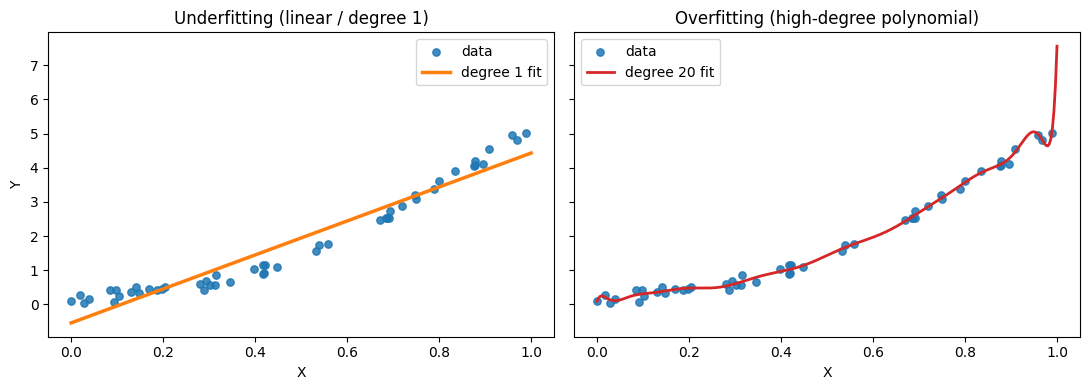

Train R^2 degree 1: 0.935
Train R^2 degree 20: 0.997
High train R^2 on degree 20 does not mean the wiggles will generalize.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline

np.random.seed(1)
X = np.random.rand(50, 1)
y = (
    0.7 * (X ** 5)
    - 2.1 * (X ** 4)
    + 2.7 * (X ** 3)
    + 3.5 * (X ** 2)
    + 0.3 * X
    + 0.4 * np.random.rand(50, 1)
)

# Smooth x-grid for drawing the fitted curve
x_grid = np.linspace(0, 1, 300).reshape(-1, 1)

underfit = make_pipeline(
    PolynomialFeatures(1), StandardScaler(), LinearRegression()
)
overfit = make_pipeline(
    PolynomialFeatures(20), StandardScaler(), LinearRegression()
)
underfit.fit(X, y)
overfit.fit(X, y)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

axes[0].scatter(X, y, s=28, alpha=0.85, label="data")
axes[0].plot(x_grid, underfit.predict(x_grid), color="C1", lw=2.5, label="degree 1 fit")
axes[0].set_title("Underfitting (linear / degree 1)")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")
axes[0].legend(loc="best")

axes[1].scatter(X, y, s=28, alpha=0.85, label="data")
axes[1].plot(x_grid, overfit.predict(x_grid), color="C3", lw=2.0, label="degree 20 fit")
axes[1].set_title("Overfitting (high-degree polynomial)")
axes[1].set_xlabel("X")
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()

print("Train R^2 degree 1:", round(underfit.score(X, y), 3))
print("Train R^2 degree 20:", round(overfit.score(X, y), 3))
print("High train R^2 on degree 20 does not mean the wiggles will generalize.")


**Observe:**

- Left: the straight line misses the curve → **high bias / underfit**.
- Right: the high-degree curve can snake through the cloud of points → **low training error, high variance / overfit**.
- Next we quantify this with train vs test Adjusted $R^2$ and MSE across many degrees.


# Quiz 5

**Does the model LR = 5*f1 + 0*f1^2 + 0*f1^3 + 0*f1^4 underfit, overfit ?**

- Underfit
- Overfit

# 12. Underfitting / Overfitting Code

Now use **100** points, a train/test split, and polynomial degrees **1 through 99**.

We plot:

- Adjusted R-squared (train vs test)
- MSE (train vs test)

**Pedagogy note on `adj_r`:** Adjusted R-squared must use the number of columns in the **transformed** feature matrix (after `PolynomialFeatures`), not the original single column of $X$. In the loop below we transform first, then call `adj_r` with that matrix so $p$ is correct.
 If degree is so high that the number of polynomial columns meets or exceeds $n - 1$, Adjusted $R^2$ is undefined and we plot it as missing (`nan`).


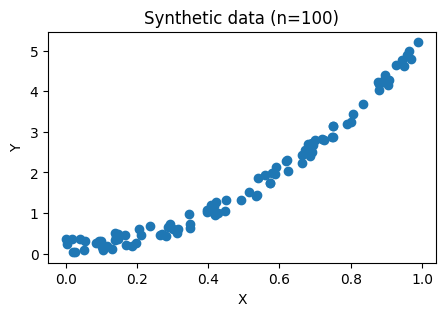

Train size: 80 | Test size: 20


In [7]:
# Generate 100 points
np.random.seed(1)
X = np.random.rand(100, 1)
y = (
    0.7 * (X ** 5)
    - 2.1 * (X ** 4)
    + 2.7 * (X ** 3)
    + 3.5 * (X ** 2)
    + 0.3 * X
    + 0.4 * np.random.rand(100, 1)
)

fig = plt.figure(figsize=(5, 3))
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Synthetic data (n=100)")
plt.show()

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)
print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])

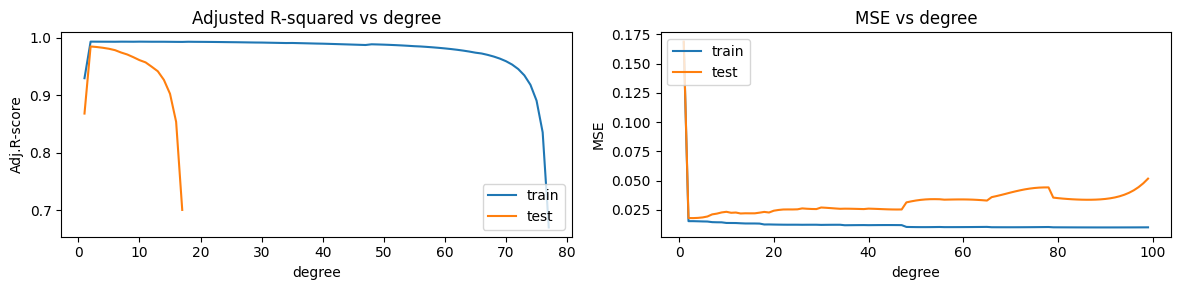

In [8]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

degrees = 100  # loop degree in range(1, degrees) => 1..99
train_scores = []
test_scores = []
train_loss = []
test_loss = []

for degree in range(1, degrees):
    poly = PolynomialFeatures(degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_poly)
    X_test_scaled = scaler.transform(X_test_poly)

    model = LinearRegression()
    model.fit(X_train_scaled, y_train)

    # sklearn r2 via score; adj_r uses transformed feature column count
    train_r2 = model.score(X_train_scaled, y_train)
    test_r2 = model.score(X_test_scaled, y_test)

    train_scores.append(adj_r(train_r2, X_train_scaled, y_train))
    test_scores.append(adj_r(test_r2, X_test_scaled, y_test))

    train_loss.append(mean_squared_error(y_train, model.predict(X_train_scaled)))
    test_loss.append(mean_squared_error(y_test, model.predict(X_test_scaled)))

deg_axis = list(range(1, degrees))

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(deg_axis, train_scores, label="train")
axes[0].plot(deg_axis, test_scores, label="test")
axes[0].legend(loc="lower right")
axes[0].set_xlabel("degree")
axes[0].set_ylabel("Adj.R-score")
axes[0].set_title("Adjusted R-squared vs degree")

axes[1].plot(deg_axis, train_loss, label="train")
axes[1].plot(deg_axis, test_loss, label="test")
axes[1].legend(loc="upper left")
axes[1].set_xlabel("degree")
axes[1].set_ylabel("MSE")
axes[1].set_title("MSE vs degree")

plt.tight_layout()
plt.show()

**Observe:**

- At **high** degrees, test performance often drops sharply $\Rightarrow$ **overfitting**.
- At **very low** degrees, both train and test stay weak $\Rightarrow$ **underfitting**.

**Think:** Roughly where is your sweet spot on these plots? Would Occam's Razor push you left or right within that plateau?

# 13. Bias-Variance Tradeoff

Prediction error on unseen data can be understood (conceptually) as a tradeoff:

$$
\text{Expected error} \approx \text{Bias}^{2} + \text{Variance} + \text{Irreducible noise}
$$

## Intuition (dartboard)

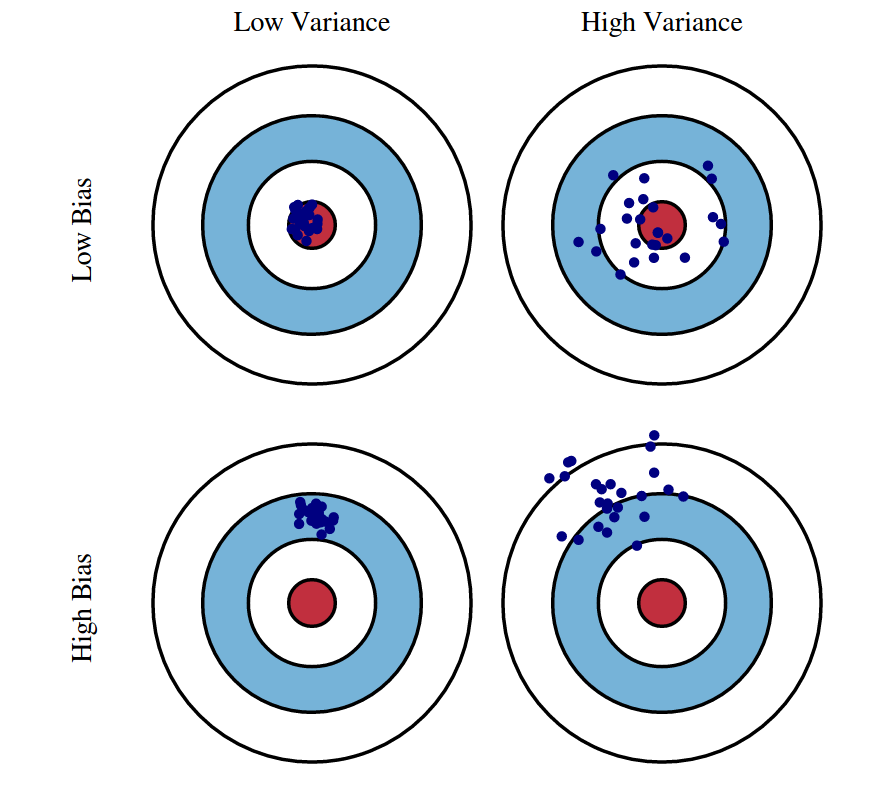

- **Bias:** are predictions systematically off the target?
- **Variance:** how much do predictions bounce if we retrain on a new sample from the same process?

Ideal: **low bias and low variance** (hits near the bullseye consistently).

## Relation to under / overfit

| Situation | Bias | Variance | Typical cause |
|---|---|---|---|
| Underfitting | **High** | **Low** | Model too simple; misses patterns |
| Overfitting | **Low** (on train-like points) | **High** | Model too complex; sensitive to sample noise |
| Good fit | Low | Low | Complexity matched to signal |

### Underfitted model

- Predictions mostly off $\Rightarrow$ **high bias**
- Small change in inputs does not wildly change predictions (simple hypothesis) $\Rightarrow$ **low variance**

### Overfitted model

- Can look great on training-like points, fail on slightly different ones $\Rightarrow$ bias not always high on train, but generalization suffers
- Slight changes in features (or dataset) swing predictions $\Rightarrow$ **high variance**

**Discuss:** Using the degree plots from the previous section, where do you see high bias? Where do you see high variance?

# Quiz 6

**If model has train perf = 90% and test perf = 91%, then:**

- Model is overfitting
- Model is Underfitting
- Model is Perfectly fitting
- Cant say

# Wrap-up

You should now be able to:

1. Compare Batch / SGD / Mini-Batch conceptually.
2. Explain why polynomial features keep the model linear in weights.
3. Prefer Adjusted R-squared (or train/test metrics) over raw training $R^2$ when adding powers.
4. Use Occam's Razor when several models generalize similarly.
5. Diagnose underfit vs overfit and relate them to bias and variance.

**Next habits:** always check train **and** test; increase complexity only while test performance improves (or stays comparable); then prefer the simpler model.